# 📰 News Classification

### NLP + TF-IDF + Logistic Regression

This project uses Natural Language Processing and Machine Learning
to classify news articles into predefined categories.

## 1. Import Libraries

In [6]:
# Import Libraries
### NLP + TF-IDF + Logistic Regression

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

The dataset is divided into separate training and testing datasets.
The training dataset will be used to train the model, while the testing
dataset will be used to evaluate its performance on unseen data.

In [9]:
# Load training and testing datasets

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

print("Training dataset loaded successfully!")
print("Testing dataset loaded successfully!")

Training dataset loaded successfully!
Testing dataset loaded successfully!


In [10]:
# Check the dataset dimensions

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (120000, 3)
Testing dataset shape: (7600, 3)


In [11]:
# View the first few rows

train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [12]:
test_df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [13]:
# Check column names

print("Training columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training columns:
['Class Index', 'Title', 'Description']

Testing columns:
['Class Index', 'Title', 'Description']


## 3. Understand the Dataset

In [24]:
# Check data types and missing values

print("Training Dataset Information:")
train_df.info()

Training Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 29.7 MB


In [25]:
print("\nTesting Dataset Information:")
test_df.info()


Testing Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class Index  7600 non-null   int64
 1   Title        7600 non-null   str  
 2   Description  7600 non-null   str  
dtypes: int64(1), str(2)
memory usage: 1.9 MB


In [26]:
# Now check missing values:

print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
Class Index    0
Title          0
Description    0
dtype: int64

Missing values in testing data:
Class Index    0
Title          0
Description    0
dtype: int64


In [27]:
# Check the news categories

print("Training class distribution:")
print(train_df["Class Index"].value_counts().sort_index())

Training class distribution:
Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


In [28]:
print("\nTesting class distribution:")
print(test_df["Class Index"].value_counts().sort_index())


Testing class distribution:
Class Index
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64


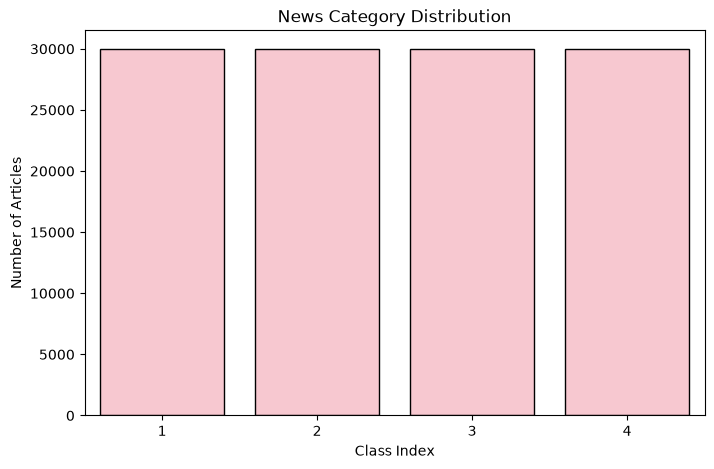

In [38]:
# Visualize the class distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="Class Index",
    color='pink', edgecolor='black'
)

plt.title("News Category Distribution")
plt.xlabel("Class Index")
plt.ylabel("Number of Articles")
plt.show()

## 4. Create Text Feature

The `Title` and `Description` columns contain complementary information
about each news article. They will be combined into a single text feature
for NLP processing.

In [30]:
# Combine Title and Description

train_df["Text"] = train_df["Title"] + " " + train_df["Description"]
test_df["Text"] = test_df["Title"] + " " + test_df["Description"]

print("Text feature created successfully!")

Text feature created successfully!


In [31]:
# View the new feature

train_df[["Title", "Description", "Text"]].head()

,Title,Description,Text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [32]:
# Check the text length

train_df["Text_Length"] = train_df["Text"].str.len()

print(train_df["Text_Length"].describe())

count    120000.000000
mean        236.460025
std          66.529799
min          17.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: Text_Length, dtype: float64


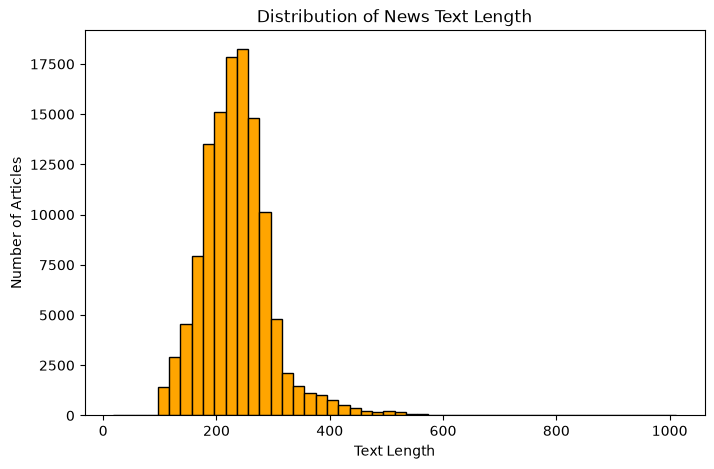

In [36]:
# Visualze it 

plt.figure(figsize=(8, 5))

plt.hist(train_df["Text_Length"], bins=50,color='orange', edgecolor='black')

plt.title("Distribution of News Text Length")
plt.xlabel("Text Length")
plt.ylabel("Number of Articles")

plt.show()

## 5. NLP Text Preprocessing

The news text is cleaned and normalized before feature extraction.
This helps reduce unnecessary variation in the text and prepares it
for TF-IDF vectorization.

In [39]:
# Create the preprocessing function

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [40]:
# Test the function

sample_text = train_df["Text"].iloc[0]

print("Original Text:")
print(sample_text)

print("\nCleaned Text:")
print(clean_text(sample_text))

Original Text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Cleaned Text:
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


In [41]:
# Apply preprocessing

train_df["Clean_Text"] = train_df["Text"].apply(clean_text)
test_df["Clean_Text"] = test_df["Text"].apply(clean_text)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


In [42]:
# Compare before and after

print("Original:")
print(train_df["Text"].iloc[0])

print("\nCleaned:")
print(train_df["Clean_Text"].iloc[0])

Original:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Cleaned:
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


## 6. Prepare Features and Target

The cleaned news text will be used as the input feature, while
`Class Index` will be used as the target variable.

In [43]:
# Create X and y

# Training data
X_train = train_df["Clean_Text"]
y_train = train_df["Class Index"]

# Testing data
X_test = test_df["Clean_Text"]
y_test = test_df["Class Index"]

print("Training features:", X_train.shape)
print("Training target:", y_train.shape)

print("Testing features:", X_test.shape)
print("Testing target:", y_test.shape)

Training features: (120000,)
Training target: (120000,)
Testing features: (7600,)
Testing target: (7600,)


In [44]:
# Check the target labels

print("Training labels:")
print(y_train.unique())

print("\nTesting labels:")
print(y_test.unique())

Training labels:
[3 4 2 1]

Testing labels:
[3 4 2 1]


In [45]:
# Verify one complete example

print("News:")
print(X_train.iloc[0])

print("\nCategory:")
print(y_train.iloc[0])

News:
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again

Category:
3


## 7. TF-IDF Vectorization

TF-IDF is used to transform the cleaned news articles into numerical
feature vectors that can be used by the Logistic Regression classifier.

In [47]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    ngram_range=(1, 2)
)

print("TF-IDF vectorizer created successfully!")

TF-IDF vectorizer created successfully!


In [48]:
# Fit TF-IDF on Training Data

X_train_tfidf = tfidf.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (120000, 50000)


In [49]:
# Transform the Test Data

X_test_tfidf = tfidf.transform(X_test)

print("Testing TF-IDF shape:", X_test_tfidf.shape)

Testing TF-IDF shape: (7600, 50000)


In [50]:
# Check the Sparse Matrix

print("Training matrix type:", type(X_train_tfidf))
print("Testing matrix type:", type(X_test_tfidf))

Training matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Testing matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [51]:
# Check a few feature names

feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of features: 50000

First 20 features:
['aa' 'aa billion' 'aaa' 'aapl' 'aapl news' 'aaplo' 'aaron'
 'aaron peirsol' 'aaron rodgers' 'ab' 'ababa' 'abandon'
 'abandon microsoft' 'abandon nuclear' 'abandoned' 'abandoned plans'
 'abandoning' 'abandons' 'abarrel' 'abarrel mark']


## 8. Logistic Regression Model

Logistic Regression is used to classify the news articles into
four predefined categories based on their TF-IDF features.

In [52]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [53]:
# Train the model

logistic_model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [54]:
# Predict test data

y_pred = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [56]:
# Look at a few predictions

print("Actual labels:")
print(y_test.iloc[10:50].values)

print("\nPredicted labels:")
print(y_pred[10:50])

Actual labels:
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 2 2 2 2 2 2 1 1 1 1 1 1 1 1 2 3 1 4 2 2 1
 4 1 2]

Predicted labels:
[4 4 4 4 4 4 4 4 4 3 3 4 4 3 3 4 2 2 2 2 2 2 1 1 1 1 3 1 1 1 2 3 1 4 2 2 1
 3 1 2]


## 9. Calculate Accuracy

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.9211
Test Accuracy: 92.11%


## 10. Model Evaluation

The classification report provides precision, recall, F1-score,
and support for each news category.

In [58]:
# Generate classification report

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:

              precision    recall  f1-score   support

           1       0.94      0.91      0.93      1900
           2       0.96      0.98      0.97      1900
           3       0.89      0.89      0.89      1900
           4       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



## 11. Confusion Matrix

Next, we'll see which categories the model is confusing with each other.

In [59]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1733   53   68   46]
 [  14 1867   13    6]
 [  49   15 1689  147]
 [  45   18  126 1711]]


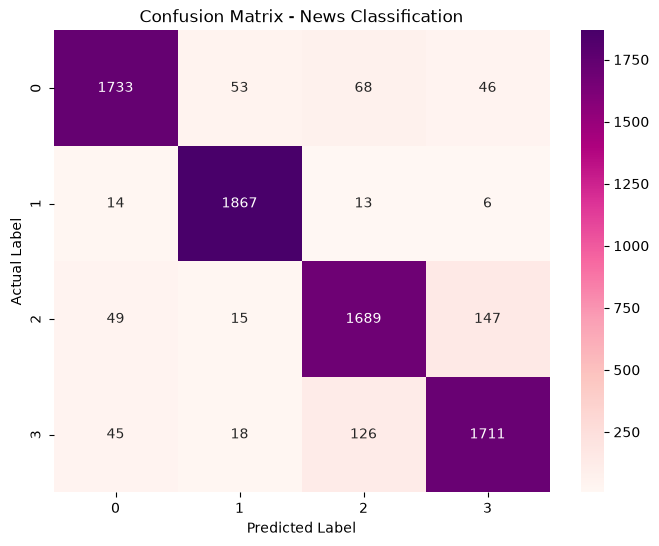

In [67]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdPu"
)

plt.title("Confusion Matrix - News Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

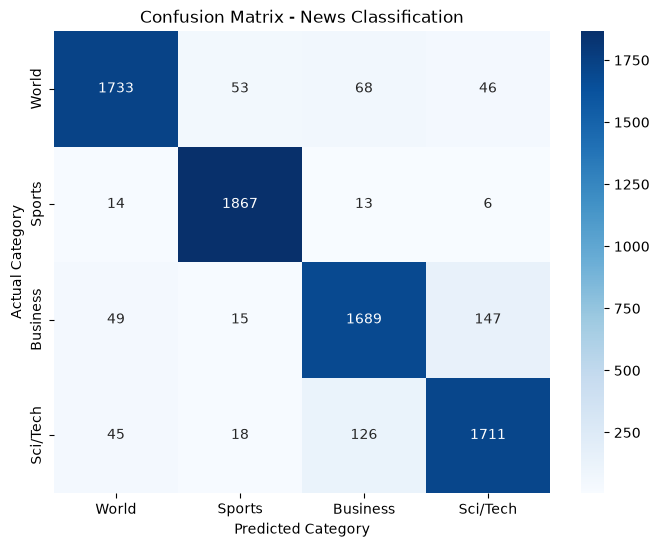

In [68]:
# Add meaningful category names - Instead of showing 1, 2, 3, 4, we'll use the actual AG News categories:

class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix - News Classification")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

## 12. Test the Model with New News

The trained model is tested on new, unseen news text to demonstrate
real-world classification.

In [69]:
# Create a prediction function

def predict_news(news_text):
    # Clean the input text
    cleaned_text = clean_text(news_text)
    
    # Convert text into TF-IDF features
    text_tfidf = tfidf.transform([cleaned_text])
    
    # Predict category
    prediction = logistic_model.predict(text_tfidf)[0]
    
    # Map class index to category
    categories = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Sci/Tech"
    }
    
    return categories[prediction]

In [70]:
# Test it

news = """
The national football team secured a dramatic victory after scoring
two goals in the final ten minutes of the match.
"""

result = predict_news(news)

print("News:")
print(news)

print("\nPredicted Category:", result)

News:

The national football team secured a dramatic victory after scoring
two goals in the final ten minutes of the match.


Predicted Category: Sports


In [71]:
news = """
A technology company has introduced a new artificial intelligence
system designed to improve the performance of personal computers.
"""

print("Predicted Category:", predict_news(news))

Predicted Category: Sci/Tech


In [72]:
news = """
Global stock markets rose after investors responded positively to
the latest corporate earnings reports.
"""

print("Predicted Category:", predict_news(news))

Predicted Category: Business


## 13. Prediction with Class Probabilities

The trained Logistic Regression model can also provide probability
estimates for each news category. This allows us to see the model's
confidence across the available classes.

In [74]:
#Create an improved prediction function

def predict_news_with_probability(news_text):
    
    # Clean the news text
    cleaned_text = clean_text(news_text)
    
    # Convert text to TF-IDF
    text_tfidf = tfidf.transform([cleaned_text])
    
    # Predict class
    prediction = logistic_model.predict(text_tfidf)[0]
    
    # Get probabilities
    probabilities = logistic_model.predict_proba(text_tfidf)[0]
    
    # Category mapping
    categories = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Sci/Tech"
    }
    
    # Create probability dictionary
    probability_dict = {
        categories[class_index]: probability
        for class_index, probability 
        in zip(logistic_model.classes_, probabilities)
    }
    
    return categories[prediction], probability_dict

In [75]:
# Test it
news = """
The national football team secured a dramatic victory after scoring
two goals in the final ten minutes of the match.
"""

prediction, probabilities = predict_news_with_probability(news)

print("Predicted Category:", prediction)

print("\nCategory Probabilities:")

for category, probability in probabilities.items():
    print(f"{category}: {probability:.2%}")

Predicted Category: Sports

Category Probabilities:
World: 0.31%
Sports: 99.55%
Business: 0.07%
Sci/Tech: 0.07%


## 14. Visualize Prediction Probability

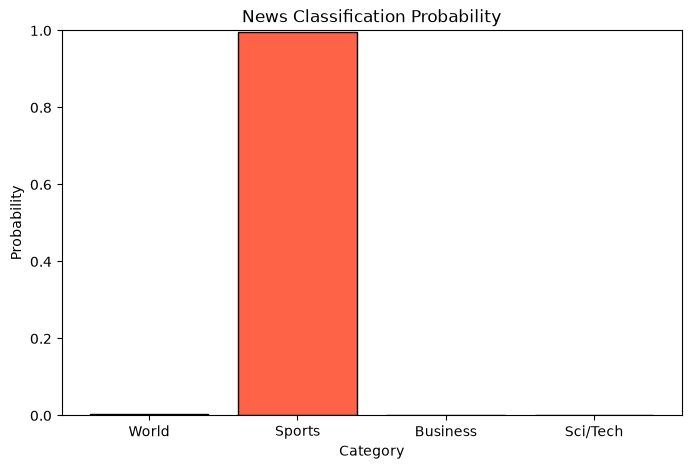

In [86]:
plt.figure(figsize=(8, 5))

plt.bar(
    probabilities.keys(),
    probabilities.values(),
    color='tomato', 
    edgecolor='black'
)

plt.title("News Classification Probability")
plt.xlabel("Category")
plt.ylabel("Probability")

plt.ylim(0, 1)

plt.show()

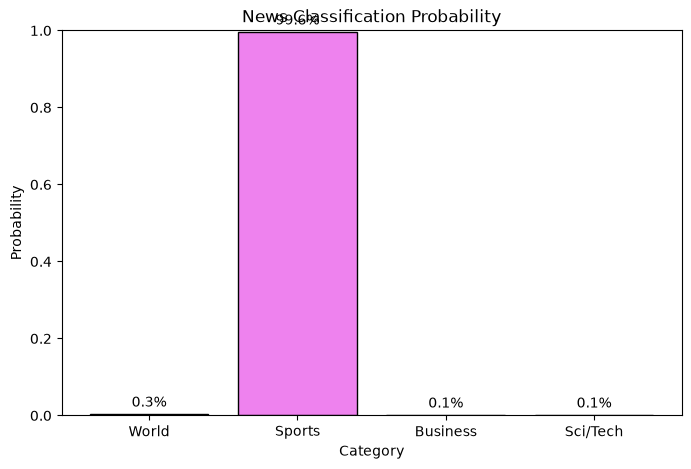

In [85]:
# Add percentage labels

plt.figure(figsize=(8, 5))

bars = plt.bar(
    probabilities.keys(),
    probabilities.values(),
    color='violet', 
    edgecolor='black'
)

plt.title("News Classification Probability")
plt.xlabel("Category")
plt.ylabel("Probability")

plt.ylim(0, 1)

for bar, probability in zip(bars, probabilities.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{probability:.1%}",
        ha="center"
    )

plt.show()

## 15. Save the Trained Mode

In [87]:
import joblib

In [88]:
joblib.dump(logistic_model, "model/logistic_model.pkl")
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


## 16. Important Features by News Category

The Logistic Regression coefficients are analyzed to identify the
words that contribute most strongly to each news category.

### Analyze Important Words for Each Category

Because Logistic Regression assigns coefficients to TF-IDF features, we can inspect which words are most strongly associated with each news category.

In [89]:
# Get feature names

feature_names = np.array(tfidf.get_feature_names_out())

In [90]:
# Find important words

for class_index, class_name in zip(
    logistic_model.classes_,
    ["World", "Sports", "Business", "Sci/Tech"]
):
    
    class_coefficients = logistic_model.coef_[class_index - 1]
    
    top_indices = class_coefficients.argsort()[-15:][::-1]
    
    print(f"\nTop words for {class_name}:")
    print(feature_names[top_indices])


Top words for World:
['iraq' 'afp' 'iraqi' 'canadian press' 'nuclear' 'president'
 'athens greece' 'afp afp' 'palestinian' 'military' 'darfur' 'york stocks'
 'iran' 'killed' 'leader']

Top words for Sports:
['coach' 'cup' 'team' 'league' 'sports' 'season' 'olympic' 'players'
 'stadium' 'baseball' 'nba' 'night' 'formula' 'athens' 'teams']

Top words for Business:
['oil' 'economy' 'company' 'bank' 'hellip' 'economic' 'corp' 'tax'
 'dollar' 'amp' 'airlines' 'cbsmw' 'retailers' 'business' 'york reuters']

Top words for Sci/Tech:
['internet' 'space' 'nasa' 'software' 'scientists' 'microsoft' 'apple'
 'technology' 'web' 'linux' 'online' 'reuters reuters' 'computer' 'study'
 'science']


## 17. Final Model Performance

The News Classification model was trained using TF-IDF features and
Logistic Regression.

### Dataset
- Training samples: 120,000
- Testing samples: 7,600
- Number of classes: 4

### Classes
- World
- Sports
- Business
- Sci/Tech

### Model
- TF-IDF Vectorization
- Logistic Regression

### Performance
- Test Accuracy: 92%
- Macro F1-score: 0.92
- Weighted F1-score: 0.92

The model was also evaluated using precision, recall, F1-score,
and a confusion matrix.

## 18. Save the Final Model Files

In [94]:
import joblib

joblib.dump(
    logistic_model,
    "logistic_model.pkl"
)

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [93]:
import joblib

joblib.dump(
    tfidf,
    "model/tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


In [95]:
# Test the saved files

import joblib

model = joblib.load("model/logistic_model.pkl")
vectorizer = joblib.load("model/tfidf_vectorizer.pkl")

print("Model loaded:", type(model).__name__)
print("Vectorizer loaded:", type(vectorizer).__name__)

Model loaded: LogisticRegression
Vectorizer loaded: TfidfVectorizer


In [96]:
sample_news = """
The football team secured a dramatic victory
after scoring two goals in the final minutes of the match.
"""

sample_vector = vectorizer.transform([sample_news])

prediction = model.predict(sample_vector)[0]

categories = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

print("Predicted Category:", categories[prediction])

Predicted Category: Sports
